# Designing and Implementing ETL Pipelines

## 1. Introduction to ETL <a name="intro"></a>

**Extract** – Pull data from source systems (CSV, API, database, Kafka, etc.).  
**Transform** – Clean, enrich, aggregate, validate, apply business logic.  
**Load** – Write transformed data into target (data warehouse, lake, dashboard DB, etc.).

ETL pipelines power analytics, ML training, reporting, and compliance. A well-designed pipeline is **idempotent**, **observable**, and **scalable**.

## 2. ETL vs ELT <a name="etl-vs-elt"></a>

| Aspect              | ETL (Traditional)                  | ELT (Modern Cloud)                  |
|---------------------|------------------------------------|-------------------------------------|
| Transformation      | Before loading                     | After loading (in warehouse)        |
| Storage cost        | Lower (only clean data stored)     | Higher (raw + transformed)          |
| Compute location    | ETL server                         | Warehouse engine (Snowflake, BigQuery)|
| Best for            | On-prem, regulated industries      | Cloud-native, huge volumes          |

In this notebook we build classic **ETL**. You can later convert it to ELT by skipping the Transform step here and using dbt or warehouse SQL.

## 3. Designing an ETL Pipeline <a name="design"></a>

Follow these 7 steps **before writing a single line of code**:

1. **Requirements** – What questions must the data answer? SLAs?
2. **Source Analysis** – Format, volume, change frequency, schema evolution.
3. **Transformation Rules** – Business logic, data quality rules, deduplication.
4. **Target Schema** – Star/snowflake, partitioning strategy.
5. **Error & Recovery** – Retry policy, dead-letter queue, alerts.
6. **Scheduling & Orchestration** – Cron, Airflow, Dagster.
7. **Monitoring** – Data volume, latency, quality metrics (Great Expectations).


In [1]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime
import logging
import os

# Setup logging
logging.basicConfig(
    filename='etl_pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

print("All libraries imported successfully!")

All libraries imported successfully!


**Business Scenario**

You work for an e-commerce company. Daily sales CSV arrives from the order system. You must:
- Clean & enrich the data
- Calculate total revenue per order
- Load into analytical SQLite DB + backup CSV

We will simulate the source file.

In [2]:
# === 5.0 Create sample source data (real world: replace with your file/API) ===
raw_data = {
    'order_id': [1001, 1002, 1003, 1004, 1005, None],
    'customer_id': [501, 502, 501, 503, 504, 505],
    'product': ['Laptop', 'Smartphone', 'Tablet', 'Monitor', 'Keyboard', 'Mouse'],
    'quantity': [2, 1, 3, 2, 5, 10],
    'unit_price': [899.99, 599.99, 299.99, 199.99, 49.99, 24.99],
    'order_date': ['2025-03-01', '2025-03-01', '2025-03-02', None, '2025-03-02', '2025-03-03'],
    'status': ['completed', 'completed', 'completed', 'pending', 'completed', 'completed']
}

df_raw = pd.DataFrame(raw_data)
df_raw.to_csv('raw_sales_2025-03-21.csv', index=False)

print("Raw source file created: raw_sales_2025-03-21.csv")
df_raw

Raw source file created: raw_sales_2025-03-21.csv


,order_id,customer_id,product,quantity,unit_price,order_date,status
0,1001.0,501,Laptop,2,899.99,2025-03-01,completed
1,1002.0,502,Smartphone,1,599.99,2025-03-01,completed
2,1003.0,501,Tablet,3,299.99,2025-03-02,completed
3,1004.0,503,Monitor,2,199.99,None,pending
4,1005.0,504,Keyboard,5,49.99,2025-03-02,completed
5,NaN,505,Mouse,10,24.99,2025-03-03,completed


### Extract

In [3]:
def extract(source_path: str) -> pd.DataFrame:
    """Extract stage – can be extended to API, SQL, S3, etc."""
    logging.info(f"Extracting from {source_path}")
    df = pd.read_csv(source_path)
    logging.info(f"Extracted {len(df)} rows")
    return df

df_extracted = extract('raw_sales_2025-03-21.csv')
df_extracted.head()

,order_id,customer_id,product,quantity,unit_price,order_date,status
0,1001.0,501,Laptop,2,899.99,2025-03-01,completed
1,1002.0,502,Smartphone,1,599.99,2025-03-01,completed
2,1003.0,501,Tablet,3,299.99,2025-03-02,completed
3,1004.0,503,Monitor,2,199.99,NaN,pending
4,1005.0,504,Keyboard,5,49.99,2025-03-02,completed


### Transform

In [4]:
def transform(df: pd.DataFrame) -> pd.DataFrame:
    """Transform stage – production-ready cleaning & enrichment"""
    logging.info("Starting transformation")
    
    df = df.copy()
    
    # 1. Data type fixes
    df['order_id'] = pd.to_numeric(df['order_id'], errors='coerce').fillna(0).astype(int)
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
    df['order_date'] = df['order_date'].fillna(pd.Timestamp.today().normalize())
    
    # 2. Derived columns
    df['total_amount'] = df['quantity'] * df['unit_price']
    df['transformed_at'] = datetime.now()
    
    # 3. Quality checks & filtering
    df = df[df['quantity'] > 0]                    # remove negative quantities
    df = df[df['total_amount'] > 0]                # business rule
    
    # 4. Deduplication (idempotency)
    df = df.drop_duplicates(subset=['order_id'])
    
    logging.info(f"Transformed to {len(df)} rows. Total revenue: ${df['total_amount'].sum():,.2f}")
    return df

df_transformed = transform(df_extracted)
df_transformed

,order_id,customer_id,product,quantity,unit_price,order_date,status,total_amount,transformed_at
0,1001,501,Laptop,2,899.99,2025-03-01,completed,1799.98,2026-03-21 09:27:51.622230
1,1002,502,Smartphone,1,599.99,2025-03-01,completed,599.99,2026-03-21 09:27:51.622230
2,1003,501,Tablet,3,299.99,2025-03-02,completed,899.97,2026-03-21 09:27:51.622230
3,1004,503,Monitor,2,199.99,2026-03-21,pending,399.98,2026-03-21 09:27:51.622230
4,1005,504,Keyboard,5,49.99,2025-03-02,completed,249.95,2026-03-21 09:27:51.622230
5,0,505,Mouse,10,24.99,2025-03-03,completed,249.90,2026-03-21 09:27:51.622230


### Load

   row_count  total_revenue
0          6        4199.77


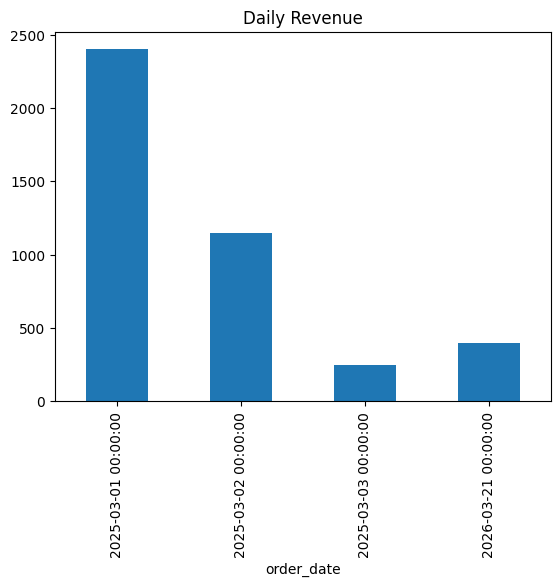

In [5]:
def load(df: pd.DataFrame, target_csv: str = 'transformed_sales.csv', db_path: str = 'analytics.db'):
    """Load stage  dual target (CSV backup + analytical DB)"""
    logging.info("Loading data")
    
    # CSV backup
    df.to_csv(target_csv, index=False)
    
    # SQLite analytical store
    conn = sqlite3.connect(db_path)
    df.to_sql('sales_fact', conn, if_exists='replace', index=False)
    conn.close()
    
    logging.info(f"Loaded {len(df)} rows to {target_csv} and {db_path}")
    
    # Quick verification query
    conn = sqlite3.connect(db_path)
    verify = pd.read_sql("SELECT COUNT(*) as row_count, SUM(total_amount) as total_revenue FROM sales_fact", conn)
    conn.close()
    print(verify)

load(df_transformed)

# Optional: quick plot
import matplotlib.pyplot as plt
df_transformed.groupby('order_date')['total_amount'].sum().plot(kind='bar', title='Daily Revenue')
plt.show()

## Advanced Patterns</a>

### Full Orchestrated Pipeline Function 

In [6]:
def run_full_etl(source_path: str = 'raw_sales_2025-03-21.csv'):
    """One-click production-ready ETL function"""
    try:
        logging.info("=== ETL PIPELINE STARTED ===")
        
        df = extract(source_path)
        df = transform(df)
        load(df)
        
        logging.info("=== ETL PIPELINE COMPLETED SUCCESSFULLY ===")
        print("Full ETL pipeline executed successfully!")
        
    except Exception as e:
        logging.error(f"ETL failed: {str(e)}", exc_info=True)
        raise

# Run it!
run_full_etl()

   row_count  total_revenue
0          6        4199.77
Full ETL pipeline executed successfully!


### Incremental Load Pattern 

```python
# Example incremental logic
last_run_date = '2025-03-20'
df_new = df[df['order_date'] > last_run_date]
```

## Best Practices & Production Tips 

1. **Idempotency** – Use `if_exists='replace'` or UPSERT logic.
2. **Data Validation** – Add Great Expectations or simple asserts.
3. **Secret Management** – Never hard-code credentials (use `os.environ` or AWS Secrets).
4. **Monitoring** – Send Slack/Teams alert on failure.
5. **Testing** – Unit test each stage (`pytest`).
6. **Schema Evolution** – Use `ALTER TABLE` or dbt for production.
7. **Orchestration** – Wrap the function above in an Airflow DAG (example provided in comments below).

**Airflow DAG skeleton** (uncomment if you have Airflow):
```python
# from airflow import DAG
# task = PythonOperator(task_id='etl', python_callable=run_full_etl)
```